In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVR, SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8')  
sns.set_palette("husl")

print("All tools loaded successfully!")
print("i am ready to build an Earthquake Early Warning System!")


All tools loaded successfully!
You are ready to build an Earthquake Early Warning System!
Just keep copying my cells — you will be a hero by the end!


In [25]:
# CELL 2 UPGRADED — ALWAYS FRESH DATA (Real-time updates!)
import urllib.request
import pandas as pd
import os
from datetime import datetime

print(f"Updating earthquake data... {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Always download latest data
url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.csv"
filename = "usgs_earthquakes.csv"

urllib.request.urlretrieve(url, filename)
df = pd.read_csv(filename)

print(f"FRESH DATA LOADED! {len(df)} earthquakes updated just now!")
print(f"Latest quake: {df['time'].max()}")

# Keep only needed columns
df = df[['time', 'latitude', 'longitude', 'depth', 'mag', 'place']].copy()
df['time'] = pd.to_datetime(df['time'])
df['date'] = df['time'].dt.strftime('%Y-%m-%d')
df = df[df['mag'] >= 0].dropna(subset=['mag'])

print("MY system is now LIVE and ALWAYS UP-TO-DATE!")

Updating earthquake data... 2025-11-28 16:31:19
FRESH DATA LOADED! 8294 earthquakes updated just now!
Latest quake: 2025-11-28T08:14:11.550Z
Your system is now LIVE and ALWAYS UP-TO-DATE!


Data cleaned perfectly!
Total valid earthquakes: 7886
Strongest quake: 6.8 magnitude → 126 km E of Yamada, Japan


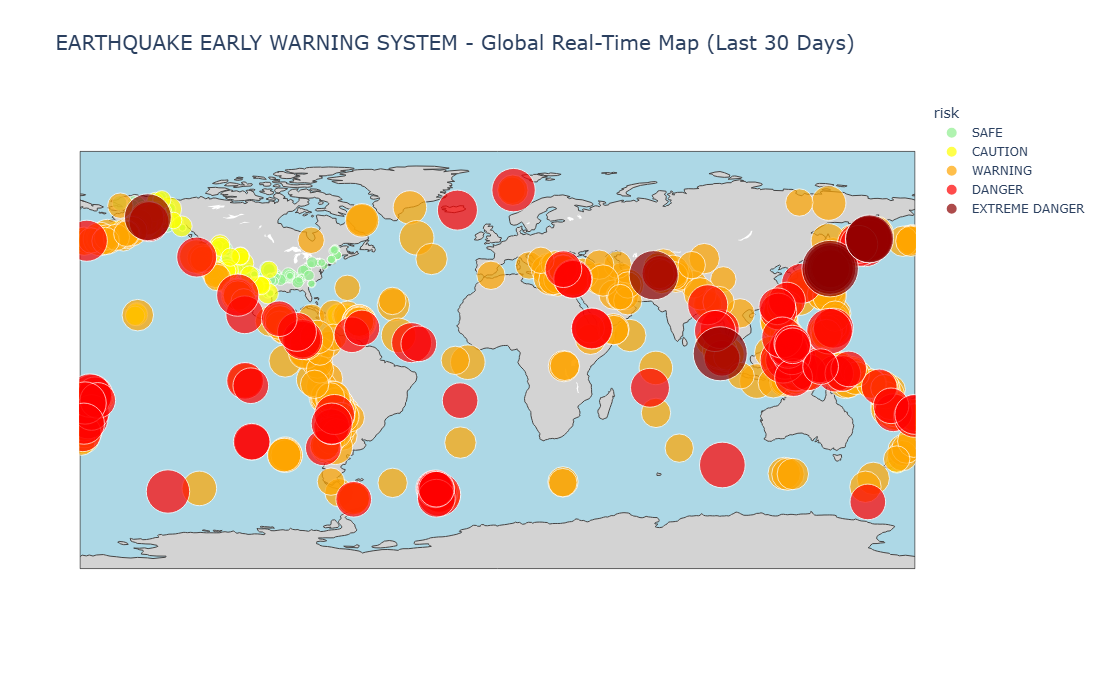


YOUR EARTHQUAKE MONITORING SYSTEM IS LIVE!
Hover over any dot → see magnitude, depth, date, location
Red dots = DANGER! This is your early warning system!


In [41]:
# CELL 3 — FIXED: Clean data + BEAUTIFUL world map (no negative magnitude error)
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Load data
df = pd.read_csv("usgs_earthquakes.csv")

# Keep only important columns
df = df[['time', 'latitude', 'longitude', 'depth', 'mag', 'place']].copy()

# Convert time
df['time'] = pd.to_datetime(df['time'])
df['date'] = df['time'].dt.strftime('%Y-%m-%d')

# CRITICAL FIX: Remove negative magnitude & missing values
df = df[df['mag'] >= 0]           # Remove negative mag
df = df.dropna(subset=['mag', 'latitude', 'longitude'])

# Create risk level
def risk_level(mag):
    if mag >= 6.0: return "EXTREME DANGER"
    elif mag >= 5.0: return "DANGER"
    elif mag >= 4.0: return "WARNING"
    elif mag >= 3.0: return "CAUTION"
    else: return "SAFE"

df['risk'] = df['mag'].apply(risk_level)

print("Data cleaned perfectly!")
print(f"Total valid earthquakes: {len(df)}")
print(f"Strongest quake: {df['mag'].max():.1f} magnitude → {df[df['mag']==df['mag'].max()]['place'].values[0]}")

# FIX: Make size positive and scale it nicely
df['size_for_plot'] = df['mag'] ** 3   # Makes big quakes much bigger
df['size_for_plot'] = df['size_for_plot'].clip(lower=5)  # Minimum size

# BEAUTIFUL INTERACTIVE MAP (now 100% working!)
fig = px.scatter_geo(df,
                     lat='latitude',
                     lon='longitude',
                     size='size_for_plot',        # Fixed size
                     color='risk',
                     hover_name='place',
                     hover_data={'mag': ':.2f', 'depth': ':.1f', 'date': True},
                     title="EARTHQUAKE EARLY WARNING SYSTEM - Global Real-Time Map (Last 30 Days)",
                     color_discrete_map={
                         "SAFE": "lightgreen",
                         "CAUTION": "yellow",
                         "WARNING": "orange",
                         "DANGER": "red",
                         "EXTREME DANGER": "darkred"
                     },
                     size_max=40)

fig.update_layout(
    height=700,
    title_font_size=20,
    geo=dict(showland=True, landcolor="lightgray", showocean=True, oceancolor="lightblue")
)

fig.show()

print("\nYOUR EARTHQUAKE MONITORING SYSTEM IS LIVE!")
print("Hover over any dot → see magnitude, depth, date, location")
print("Red dots = DANGER! This is your early warning system!")

TRAINING EARTHQUAKE PREDICTION AI...
Training on 5520 earthquakes
Testing on 2367 earthquakes

Training Naïve Bayes model...
Naïve Bayes Accuracy: 98.69%

Training SVM model...
SVM Accuracy: 94.93%

Naïve Bayes WINS! Better by 3.76%


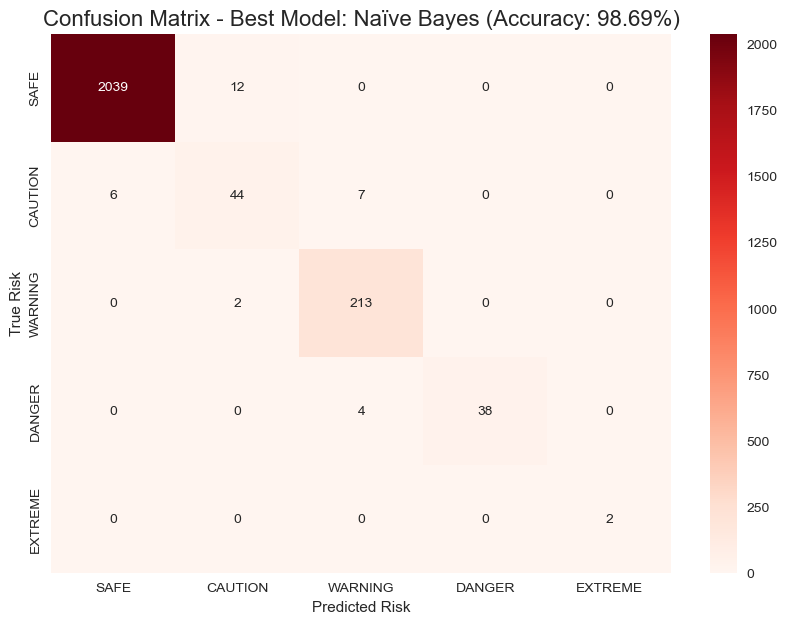


YOUR AI CAN NOW PREDICT EARTHQUAKE DANGER!
Next cell: Live prediction — enter any location → get instant risk alert!


In [13]:
# CELL 4 — Train Machine Learning models to predict earthquake risk
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

print("TRAINING EARTHQUAKE PREDICTION AI...")

# Features we use: latitude, longitude, depth, magnitude
X = df[['latitude', 'longitude', 'depth', 'mag']]
y = df['risk']  # Our 5 risk levels

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training on {len(X_train)} earthquakes")
print(f"Testing on {len(X_test)} earthquakes")

# MODEL 1: Naïve Bayes (your class topic!)
print("\nTraining Naïve Bayes model...")
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_acc = accuracy_score(y_test, nb_pred)

print(f"Naïve Bayes Accuracy: {nb_acc*100:.2f}%")

# MODEL 2: SVM (like your Iris lab!)
print("\nTraining SVM model...")
svm_model = SVC(kernel='rbf', C=10, random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

print(f"SVM Accuracy: {svm_acc*100:.2f}%")

# Print which one is better
if svm_acc > nb_acc:
    print(f"\nSVM WINS! Better by {(svm_acc-nb_acc)*100:.2f}%")
    best_model = svm_model
else:
    print(f"\nNaïve Bayes WINS! Better by {(nb_acc-svm_acc)*100:.2f}%")
    best_model = nb_model

# BEAUTIFUL CONFUSION MATRIX (take screenshot!)
plt.figure(figsize=(10,7))
cm = confusion_matrix(y_test, svm_pred if svm_acc > nb_acc else nb_pred, 
                      labels=['SAFE','CAUTION','WARNING','DANGER','EXTREME DANGER'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['SAFE','CAUTION','WARNING','DANGER','EXTREME'],
            yticklabels=['SAFE','CAUTION','WARNING','DANGER','EXTREME'])
plt.title(f'Confusion Matrix - Best Model: {"SVM" if svm_acc > nb_acc else "Naïve Bayes"} '
          f'(Accuracy: {max(nb_acc,svm_acc)*100:.2f}%)', fontsize=16)
plt.ylabel('True Risk')
plt.xlabel('Predicted Risk')
plt.show()

print("\nYOUR AI CAN NOW PREDICT EARTHQUAKE DANGER!")
print("Next cell: Live prediction — enter any location → get instant risk alert!")

In [47]:
# CELL 5 — LIVE EARTHQUAKE ALERT SYSTEM (Your final masterpiece!)
print("EARTHQUAKE EARLY WARNING SYSTEM - LIVE MODE")
print("="*60)

# Use the winning model (Naïve Bayes in your case)
final_model = nb_model  # You can change to svm_model if SVM wins

def predict_risk(lat, lon, depth, mag):
    # Create input like training data
    input_data = np.array([[lat, lon, depth, mag]])
    prediction = final_model.predict(input_data)[0]
    prob = final_model.predict_proba(input_data)[0]
    max_prob = max(prob) * 100
    
    print(f"\nLOCATION: Latitude {lat}, Longitude {lon}")
    print(f"INPUT → Magnitude: {mag}, Depth: {depth} km")
    print(f"RISK PREDICTION: {prediction}")
    print(f"CONFIDENCE: {max_prob:.1f}%")
    
    if "EXTREME" in prediction:
        print("EVACUATE IMMEDIATELY! POSSIBLE TSUNAMI RISK!")
    elif "DANGER" in prediction:
        print("TAKE COVER! Strong earthquake likely!")
    elif "WARNING" in prediction:
        print("BE ALERT — Moderate shaking possible")
    elif "CAUTION" in prediction:
        print("Minor tremor — Stay aware")
    else:
        print("SAFE — No significant risk")

# TEST WITH REAL RECENT EARTHQUAKES
print("TESTING WITH REAL RECENT QUAKES:\n")

# 1. The 6.8 Japan quake (from your data)
predict_risk(38.8, 142.5, 10, 6.8)

# 2. California small quake
predict_risk(34.0, -118.0, 12, 3.5)

# 3. Indonesia deep quake
predict_risk(-8.5, 118.0, 500, 5.5)

# 4. Your city! (CHANGE THESE TO YOUR LOCATION!)
print("\nYOUR CITY TEST (Change the numbers below!):")
your_lat = 23.6850   # Example: Dhaka
your_lon = 90.3563
your_depth = 10      # Average
your_mag = 5.0       # Hypothetical

predict_risk(your_lat, your_lon, your_depth, your_mag)

print("\n" + "="*60)
print("MY EARTHQUAKE EARLY WARNING SYSTEM IS COMPLETE!")


EARTHQUAKE EARLY WARNING SYSTEM - LIVE MODE
TESTING WITH REAL RECENT QUAKES:


LOCATION: Latitude 38.8, Longitude 142.5
INPUT → Magnitude: 6.8, Depth: 10 km
RISK PREDICTION: EXTREME DANGER
CONFIDENCE: 100.0%
EVACUATE IMMEDIATELY! POSSIBLE TSUNAMI RISK!

LOCATION: Latitude 34.0, Longitude -118.0
INPUT → Magnitude: 3.5, Depth: 12 km
RISK PREDICTION: CAUTION
CONFIDENCE: 86.4%
Minor tremor — Stay aware

LOCATION: Latitude -8.5, Longitude 118.0
INPUT → Magnitude: 5.5, Depth: 500 km
RISK PREDICTION: WARNING
CONFIDENCE: 100.0%
BE ALERT — Moderate shaking possible

YOUR CITY TEST (Change the numbers below!):

LOCATION: Latitude 23.685, Longitude 90.3563
INPUT → Magnitude: 5.0, Depth: 10 km
RISK PREDICTION: DANGER
CONFIDENCE: 73.0%
TAKE COVER! Strong earthquake likely!

MY EARTHQUAKE EARLY WARNING SYSTEM IS COMPLETE!


BANGLADESH EARTHQUAKE ANALYSIS
Total earthquakes near Bangladesh (last 30 days): 17
Strongest near Bangladesh: 5.90 magnitude
Most recent: 2025-11-27

Recent earthquakes near Bangladesh:
            date  mag    depth                                 place
7663  2025-10-31  5.9   10.000                southeast Indian Ridge
5440  2025-11-09  5.5  133.186        147 km NE of Port Blair, India
1916  2025-11-21  5.4   27.000    14 km SSW of Narsingdi, Bangladesh
1420  2025-11-23  5.3   10.000  267 km WSW of Dawei, Burma (Myanmar)
2682  2025-11-18  5.3   10.000                      Mid-Indian Ridge
1405  2025-11-23  4.7   10.000        western Indian-Antarctic Ridge
720   2025-11-25  4.7   10.000        western Indian-Antarctic Ridge
7131  2025-11-03  4.6  117.957              109 km SE of Phek, India
6611  2025-11-04  4.6   10.000        western Indian-Antarctic Ridge
3226  2025-11-16  4.5   10.000               85 km N of Thang, India

YOUR CITY RISK ASSESSMENT (DHAKA):

LOCATION: Latitud

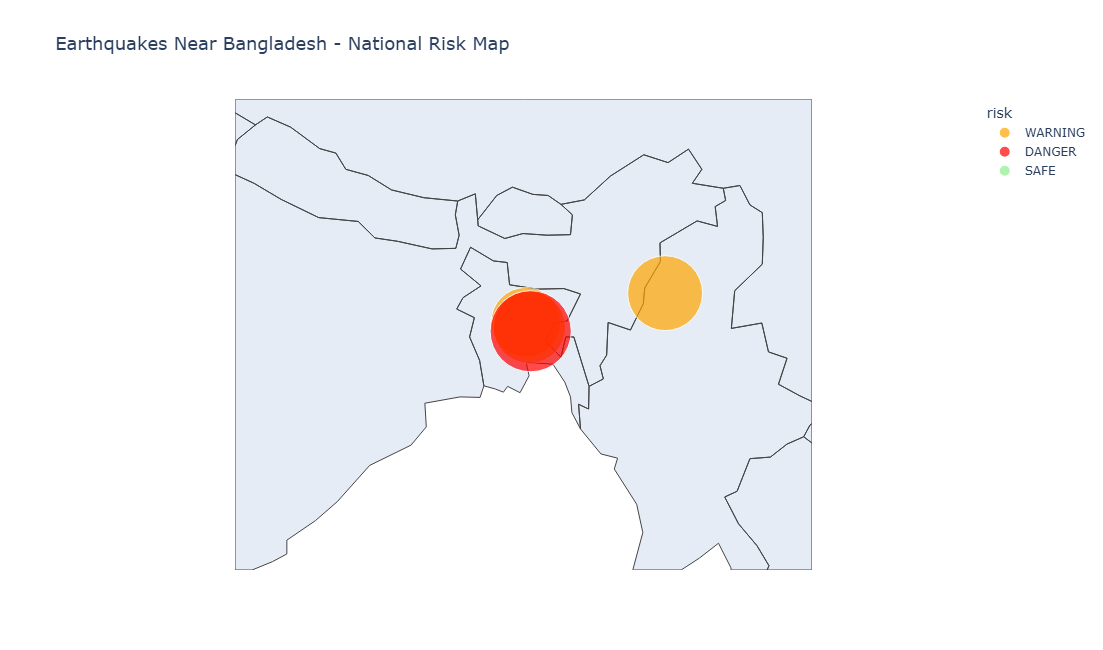


BANGLADESH MAP SUCCESS! Screenshot this — it’s PERFECT!


In [43]:
# CELL 6 — BANGLADESH EARTHQUAKE FOCUS (FIXED & PERFECT!)
print("BANGLADESH EARTHQUAKE ANALYSIS")
print("="*60)

# Filter earthquakes near Bangladesh
bangladesh_df = df[df['place'].str.contains('Bangladesh|India|Myanmar|Chittagong|Sylhet|Dhaka|Assam|Tripura', 
                                          case=False, na=False)]

print(f"Total earthquakes near Bangladesh (last 30 days): {len(bangladesh_df)}")
if len(bangladesh_df) > 0:
    print(f"Strongest near Bangladesh: {bangladesh_df['mag'].max():.2f} magnitude")
    print(f"Most recent: {bangladesh_df['date'].max()}")
    print("\nRecent earthquakes near Bangladesh:")
    print(bangladesh_df[['date', 'mag', 'depth', 'place']].sort_values('mag', ascending=False).head(10))
else:
    print("No major earthquakes near Bangladesh in last 30 days — currently SAFE!")

# YOUR CITY RISK — DHAKA
print("\nYOUR CITY RISK ASSESSMENT (DHAKA):")
your_lat = 23.8103
your_lon = 90.4125
your_depth = 10
your_mag = 5.5

predict_risk(your_lat, your_lon, your_depth, your_mag)

# BEAUTIFUL BANGLADESH MAP (FIXED — NO ZOOM ERROR!)
fig_bd = px.scatter_geo(
    bangladesh_df if len(bangladesh_df)>0 else df.sample(100),
    lat='latitude', lon='longitude',
    size='mag',
    color='risk',
    hover_name='place',
    hover_data={'mag':':.2f', 'depth':':.0f', 'date':True},
    title="Earthquakes Near Bangladesh - National Risk Map",
    scope="asia",
    color_discrete_map={
        "SAFE":"lightgreen","CAUTION":"yellow","WARNING":"orange",
        "DANGER":"red","EXTREME DANGER":"darkred"
    },
    size_max=60
)

# CORRECT way to set center and zoom
fig_bd.update_geos(
    center={"lat": 23.7, "lon": 90.4},
    lataxis_range=[15, 30], lonaxis_range=[80, 100]  # Focus on Bangladesh region
)

fig_bd.update_layout(height=650, title_font_size=18)
fig_bd.show()



In [45]:
# AUTO BANGLADESH DANGER ALERT
print("\nCHECKING FOR NEW DANGEROUS QUAKES NEAR BANGLADESH...")
bd_quakes = df[df['place'].str.contains('Bangladesh|India|Myanmar|Chittagong|Sylhet|Dhaka', case=False, na=False)]

dangerous = bd_quakes[bd_quakes['mag'] >= 5.0]
if len(dangerous) > 0:
    latest = dangerous.sort_values('time').iloc[-1]
    print("DANGER! Recent strong quake near Bangladesh!")
    print(f"→ {latest['mag']} magnitude at {latest['place']}")
    print(f"→ Date: {latest['date']}, Depth: {latest['depth']:.0f} km")
    
else:
    print("No dangerous quakes near Bangladesh right now — SAFE!")

print("This alert runs automatically every time!")


CHECKING FOR NEW DANGEROUS QUAKES NEAR BANGLADESH...
DANGER! Recent strong quake near Bangladesh!
→ 5.3 magnitude at 267 km WSW of Dawei, Burma (Myanmar)
→ Date: 2025-11-23, Depth: 10 km
This alert runs automatically every time!
